In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import time
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import xgboost as xgb
import lightgbm as lgb
import pandas as pd
import librosa
import numpy as np
import glob
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


🎵 HEART SOUND CLASSIFICATION - ENSEMBLE MODEL (CNN + XGB + LGB)
Dataset path: C:\Users\HP\Downloads\classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0\classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0
Found wav files: 3541
Using file: C:\Users\HP\Downloads\classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0\classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0\training-a\a0001.wav
Sample rate  : 16000 Hz
Duration     : 35.67 seconds
Num samples  : 570656
dtype        : float32
Amplitude range: [-0.138, 0.211]


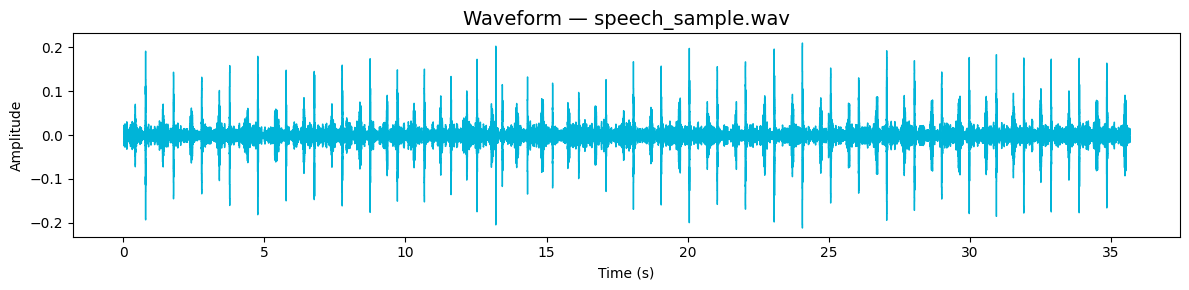

____________________________________________________________________________________________________


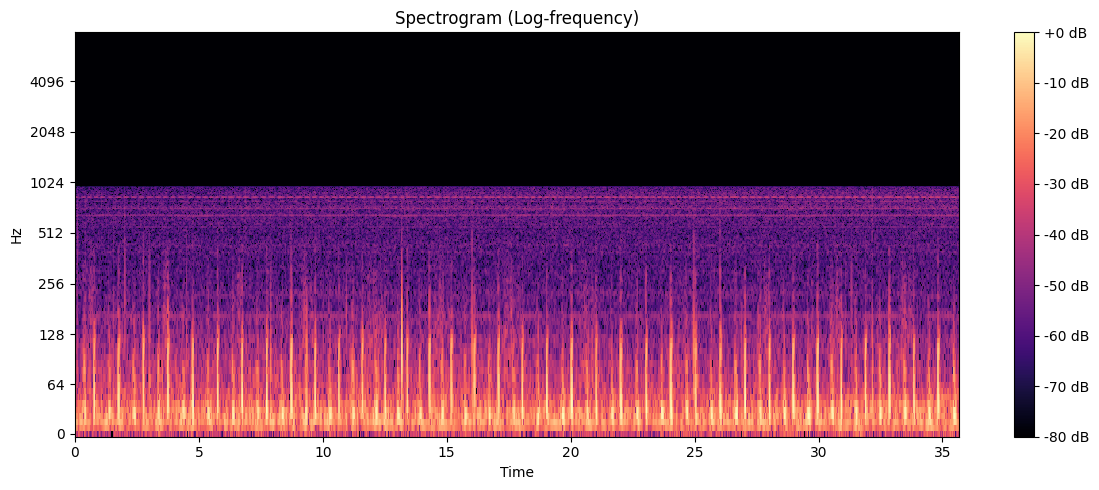

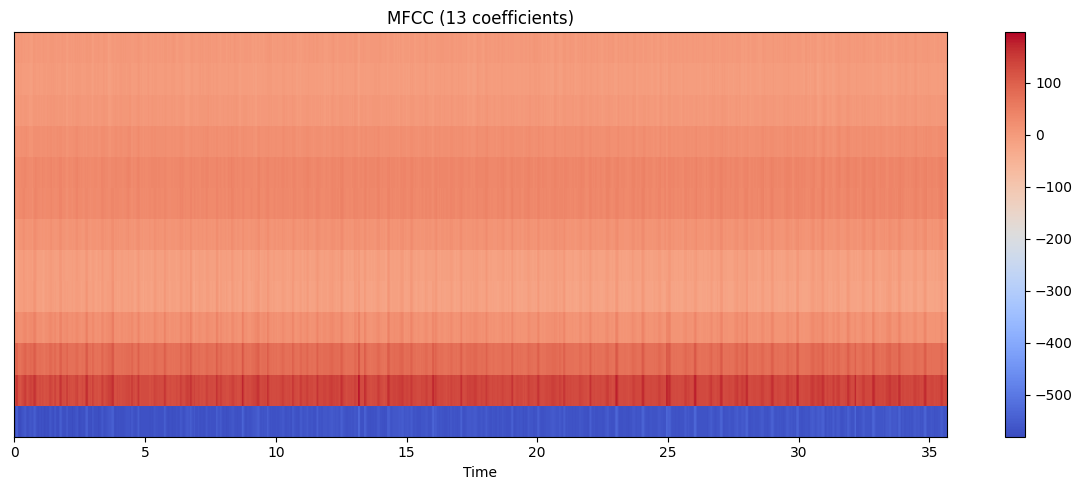


📁 Selected folders:
   Normal folders: ['training-a']
   Abnormal folders: ['training-b', 'training-e', 'training-c', 'training-d', 'training-f']

🔄 Augmentation ENABLED:
   Only Normal files: True
   Samples per file: 3

🤖 ENSEMBLE CONFIGURATION:
   CNN weight: 0.4
   XGBoost weight: 0.3
   LightGBM weight: 0.3


In [2]:
# ============================================
# 🎯 إعدادات المستخدم
# ============================================
print("\n" + "="*70)
print("🎵 HEART SOUND CLASSIFICATION - ENSEMBLE MODEL (CNN + XGB + LGB)")
print("="*70)
dataset_path = r"C:\Users\HP\Downloads\classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0\classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0"

print("Dataset path:", dataset_path)
wav_files = glob.glob(dataset_path + "/**/*.wav", recursive=True)
print("Found wav files:", len(wav_files))

if len(wav_files) == 0:
    print("No wav files found!")
    exit()

audio_file = wav_files[0]
print("Using file:", audio_file)

y, sr = librosa.load(audio_file, sr=16000, mono=True)
print(f"Sample rate  : {sr} Hz")
print(f"Duration     : {len(y)/sr:.2f} seconds")
print(f"Num samples  : {len(y)}")
print(f"dtype        : {y.dtype}")
print(f"Amplitude range: [{y.min():.3f}, {y.max():.3f}]")

# Plot the waveform
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr, color='#00B4D8')
plt.title("Waveform — speech_sample.wav", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig("waveform.png", dpi=150)
plt.show()
print("__"*50)

# ====== حدد المجلدات ======
SELECTED_FOLDERS = {
    'normal': ['training-a'],
    'abnormal': ['training-b', 'training-e', 'training-c', 'training-d', 'training-f']
}

# ====== إعدادات التدريب ======
TRAIN_SETTINGS = {
    'test_size': 0.2,
    'epochs': 100,
    'batch_size': 32,
    'balance_method': 'oversample',
    'save_model': True,
    'show_plots': True,
    'ensemble_weights': {  # أوزان النماذج في الـ Ensemble
        'cnn': 0.4,
        'xgboost': 0.3,
        'lightgbm': 0.3
    },
    'augmentation': {
        'enabled': True,
        'only_normal': True,
        'samples_per_file': 3,
        'methods': ['time_stretch', 'pitch_shift', 'noise', 'shift']
    }
}
# ... الكود الأصلي ...

# بعد تعريف y, sr من أول ملف صوتي (بعد سطر "audio_file = wav_files[0]")

if TRAIN_SETTINGS['show_plots']:
    # 1. Spectrogram باستخدام Short-Time Fourier Transform (STFT)
    plt.figure(figsize=(12, 5))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram (Log-frequency)')
    plt.tight_layout()
    plt.savefig('spectrogram.png', dpi=150)
    plt.show()

    # 2. MFCC (Mel-frequency cepstral coefficients)
    plt.figure(figsize=(12, 5))
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title('MFCC (13 coefficients)')
    plt.tight_layout()
    plt.savefig('mfcc.png', dpi=150)
    plt.show()
print("\n📁 Selected folders:")
print(f"   Normal folders: {SELECTED_FOLDERS['normal']}")
print(f"   Abnormal folders: {SELECTED_FOLDERS['abnormal']}")

if TRAIN_SETTINGS['augmentation']['enabled']:
    print(f"\n🔄 Augmentation ENABLED:")
    print(f"   Only Normal files: {TRAIN_SETTINGS['augmentation']['only_normal']}")
    print(f"   Samples per file: {TRAIN_SETTINGS['augmentation']['samples_per_file']}")

print(f"\n🤖 ENSEMBLE CONFIGURATION:")
print(f"   CNN weight: {TRAIN_SETTINGS['ensemble_weights']['cnn']}")
print(f"   XGBoost weight: {TRAIN_SETTINGS['ensemble_weights']['xgboost']}")
print(f"   LightGBM weight: {TRAIN_SETTINGS['ensemble_weights']['lightgbm']}")

In [3]:
# ============================================
# 1. دوال المعالجة الأساسية
# ============================================

def denoise(y, sr):
    """تنظيف الإشارة"""
    try:
        nyquist = sr / 2
        b, a = scipy.signal.butter(4, [20/nyquist, 200/nyquist], btype='band')
        y = scipy.signal.filtfilt(b, a, y)
        return y / (np.max(np.abs(y)) + 1e-10)
    except:
        return y

def custom_trim(y, sr, threshold=0.01):
    """قص الأجزاء الصامتة"""
    frame_length = int(sr * 0.025)
    hop_length = int(sr * 0.01)
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    mask = rms > threshold
    indices = np.where(mask)[0]
    if len(indices) > 0:
        start = indices[0] * hop_length
        end = (indices[-1] + 1) * hop_length
        return y[start:end]
    return y

# ============================================
# 2. دوال الـ Augmentation
# ============================================

def augment_audio(y, sr, method='random'):
    """تطبيق Augmentation على الإشارة الصوتية"""
    if method == 'time_stretch' or (method == 'random' and np.random.random() > 0.75):
        rate = np.random.uniform(0.8, 1.2)
        y_aug = librosa.effects.time_stretch(y, rate=rate)
        if len(y_aug) < len(y):
            y_aug = np.pad(y_aug, (0, len(y) - len(y_aug)))
        else:
            y_aug = y_aug[:len(y)]
    elif method == 'pitch_shift' or (method == 'random' and np.random.random() > 0.75):
        n_steps = np.random.randint(-2, 3)
        y_aug = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    elif method == 'noise' or (method == 'random' and np.random.random() > 0.75):
        noise_level = np.random.uniform(0.001, 0.01)
        noise = np.random.normal(0, noise_level, len(y))
        y_aug = y + noise
    elif method == 'shift' or (method == 'random' and np.random.random() > 0.75):
        shift_ms = np.random.randint(-100, 100)
        shift_samples = int(shift_ms * sr / 1000)
        y_aug = np.roll(y, shift_samples)
        if shift_samples > 0:
            y_aug[:shift_samples] = 0
        else:
            y_aug[shift_samples:] = 0
    else:
        return y
    
    y_aug = y_aug / (np.max(np.abs(y_aug)) + 1e-10)
    return y_aug

In [4]:
# Accuracy 96 - ENSEMBLE MODEL (CNN + XGBoost + LightGBM)
# %% 
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import time
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import xgboost as xgb
import lightgbm as lgb
import pandas as pd
import librosa
import numpy as np
import glob
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


🎵 HEART SOUND CLASSIFICATION - ENSEMBLE MODEL (CNN + XGB + LGB)
Dataset path: C:\Users\HP\Downloads\classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0\classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0
Found wav files: 3541
Using file: C:\Users\HP\Downloads\classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0\classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0\training-a\a0001.wav
Sample rate  : 16000 Hz
Duration     : 35.67 seconds
Num samples  : 570656
dtype        : float32
Amplitude range: [-0.138, 0.211]


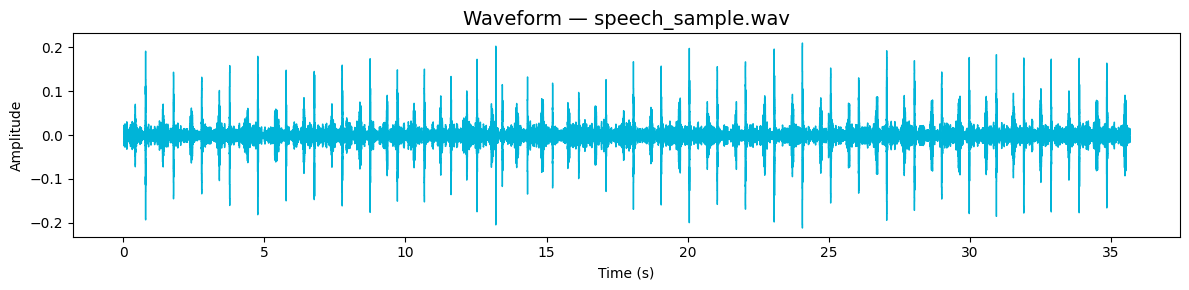

____________________________________________________________________________________________________


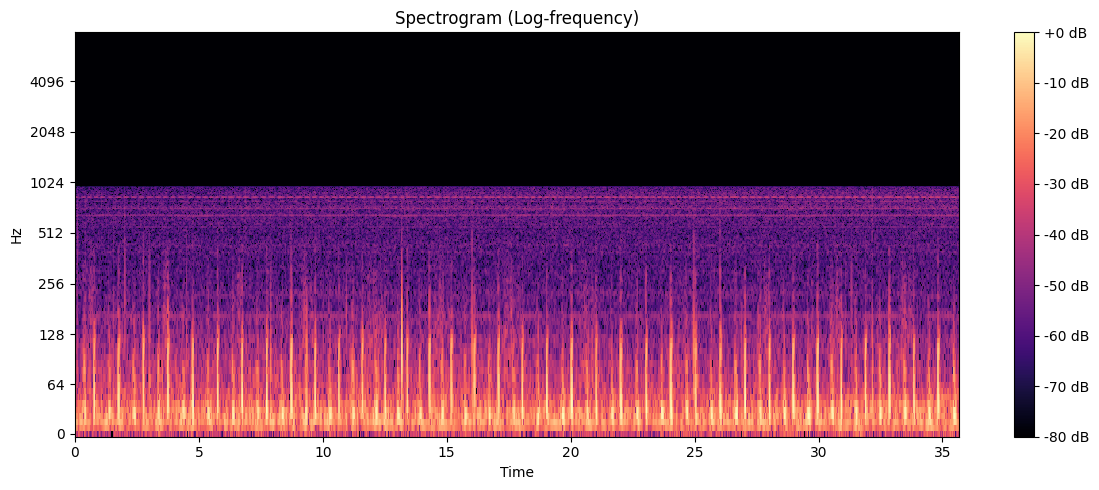

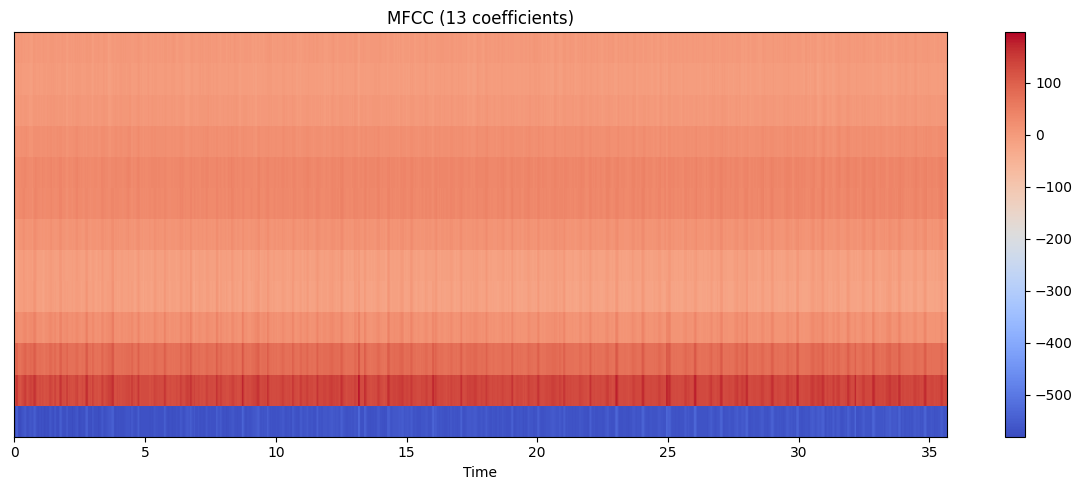


📁 Selected folders:
   Normal folders: ['training-a']
   Abnormal folders: ['training-b', 'training-e', 'training-c', 'training-d', 'training-f']

🔄 Augmentation ENABLED:
   Only Normal files: True
   Samples per file: 3

🤖 ENSEMBLE CONFIGURATION:
   CNN weight: 0.4
   XGBoost weight: 0.3
   LightGBM weight: 0.3


In [5]:
# ============================================
# 🎯 إعدادات المستخدم
# ============================================
print("\n" + "="*70)
print("🎵 HEART SOUND CLASSIFICATION - ENSEMBLE MODEL (CNN + XGB + LGB)")
print("="*70)
dataset_path = r"C:\Users\HP\Downloads\classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0\classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0"

print("Dataset path:", dataset_path)
wav_files = glob.glob(dataset_path + "/**/*.wav", recursive=True)
print("Found wav files:", len(wav_files))

if len(wav_files) == 0:
    print("No wav files found!")
    exit()

audio_file = wav_files[0]
print("Using file:", audio_file)

y, sr = librosa.load(audio_file, sr=16000, mono=True)
print(f"Sample rate  : {sr} Hz")
print(f"Duration     : {len(y)/sr:.2f} seconds")
print(f"Num samples  : {len(y)}")
print(f"dtype        : {y.dtype}")
print(f"Amplitude range: [{y.min():.3f}, {y.max():.3f}]")

# Plot the waveform
plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr, color='#00B4D8')
plt.title("Waveform — speech_sample.wav", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig("waveform.png", dpi=150)
plt.show()
print("__"*50)

# ====== حدد المجلدات ======
SELECTED_FOLDERS = {
    'normal': ['training-a'],
    'abnormal': ['training-b', 'training-e', 'training-c', 'training-d', 'training-f']
}

# ====== إعدادات التدريب ======
TRAIN_SETTINGS = {
    'test_size': 0.2,
    'epochs': 100,
    'batch_size': 32,
    'balance_method': 'oversample',
    'save_model': True,
    'show_plots': True,
    'ensemble_weights': {  # أوزان النماذج في الـ Ensemble
        'cnn': 0.4,
        'xgboost': 0.3,
        'lightgbm': 0.3
    },
    'augmentation': {
        'enabled': True,
        'only_normal': True,
        'samples_per_file': 3,
        'methods': ['time_stretch', 'pitch_shift', 'noise', 'shift']
    }
}
# ... الكود الأصلي ...

# بعد تعريف y, sr من أول ملف صوتي (بعد سطر "audio_file = wav_files[0]")

if TRAIN_SETTINGS['show_plots']:
    # 1. Spectrogram باستخدام Short-Time Fourier Transform (STFT)
    plt.figure(figsize=(12, 5))
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Spectrogram (Log-frequency)')
    plt.tight_layout()
    plt.savefig('spectrogram.png', dpi=150)
    plt.show()

    # 2. MFCC (Mel-frequency cepstral coefficients)
    plt.figure(figsize=(12, 5))
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title('MFCC (13 coefficients)')
    plt.tight_layout()
    plt.savefig('mfcc.png', dpi=150)
    plt.show()
print("\n📁 Selected folders:")
print(f"   Normal folders: {SELECTED_FOLDERS['normal']}")
print(f"   Abnormal folders: {SELECTED_FOLDERS['abnormal']}")

if TRAIN_SETTINGS['augmentation']['enabled']:
    print(f"\n🔄 Augmentation ENABLED:")
    print(f"   Only Normal files: {TRAIN_SETTINGS['augmentation']['only_normal']}")
    print(f"   Samples per file: {TRAIN_SETTINGS['augmentation']['samples_per_file']}")

print(f"\n🤖 ENSEMBLE CONFIGURATION:")
print(f"   CNN weight: {TRAIN_SETTINGS['ensemble_weights']['cnn']}")
print(f"   XGBoost weight: {TRAIN_SETTINGS['ensemble_weights']['xgboost']}")
print(f"   LightGBM weight: {TRAIN_SETTINGS['ensemble_weights']['lightgbm']}")

In [6]:
# ============================================
# 1. دوال المعالجة الأساسية
# ============================================

def denoise(y, sr):
    """تنظيف الإشارة"""
    try:
        nyquist = sr / 2
        b, a = scipy.signal.butter(4, [20/nyquist, 200/nyquist], btype='band')
        y = scipy.signal.filtfilt(b, a, y)
        return y / (np.max(np.abs(y)) + 1e-10)
    except:
        return y

def custom_trim(y, sr, threshold=0.01):
    """قص الأجزاء الصامتة"""
    frame_length = int(sr * 0.025)
    hop_length = int(sr * 0.01)
    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    mask = rms > threshold
    indices = np.where(mask)[0]
    if len(indices) > 0:
        start = indices[0] * hop_length
        end = (indices[-1] + 1) * hop_length
        return y[start:end]
    return y

# ============================================
# 2. دوال الـ Augmentation
# ============================================

def augment_audio(y, sr, method='random'):
    """تطبيق Augmentation على الإشارة الصوتية"""
    if method == 'time_stretch' or (method == 'random' and np.random.random() > 0.75):
        rate = np.random.uniform(0.8, 1.2)
        y_aug = librosa.effects.time_stretch(y, rate=rate)
        if len(y_aug) < len(y):
            y_aug = np.pad(y_aug, (0, len(y) - len(y_aug)))
        else:
            y_aug = y_aug[:len(y)]
    elif method == 'pitch_shift' or (method == 'random' and np.random.random() > 0.75):
        n_steps = np.random.randint(-2, 3)
        y_aug = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    elif method == 'noise' or (method == 'random' and np.random.random() > 0.75):
        noise_level = np.random.uniform(0.001, 0.01)
        noise = np.random.normal(0, noise_level, len(y))
        y_aug = y + noise
    elif method == 'shift' or (method == 'random' and np.random.random() > 0.75):
        shift_ms = np.random.randint(-100, 100)
        shift_samples = int(shift_ms * sr / 1000)
        y_aug = np.roll(y, shift_samples)
        if shift_samples > 0:
            y_aug[:shift_samples] = 0
        else:
            y_aug[shift_samples:] = 0
    else:
        return y
    
    y_aug = y_aug / (np.max(np.abs(y_aug)) + 1e-10)
    return y_aug

In [7]:
# ============================================
# 3. استخراج الميزات المحسن
# ============================================

def extract_features_from_audio(y, sr, max_duration=10):
    """استخراج الميزات من الإشارة الصوتية مباشرة"""
    try:
        max_samples = sr * max_duration
        if len(y) > max_samples:
            y = y[:max_samples]
        elif len(y) < sr * 0.5:
            return None
        
        y = custom_trim(y, sr, threshold=0.01)
        y = denoise(y, sr)
        
        n_fft = 1024
        hop_length = 256
        
        features_list = []
        
        # MFCC (13 coefficient)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_mels=40,
                                     n_fft=n_fft, hop_length=hop_length)
        for i in range(13):
            features_list.append(np.mean(mfcc[i]))
            features_list.append(np.std(mfcc[i]))
        
        # Delta MFCC
        mfcc_delta = librosa.feature.delta(mfcc)
        for i in range(13):
            features_list.append(np.mean(mfcc_delta[i]))
            features_list.append(np.std(mfcc_delta[i]))
        
        # Delta2 MFCC
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        for i in range(13):
            features_list.append(np.mean(mfcc_delta2[i]))
            features_list.append(np.std(mfcc_delta2[i]))
        
        # Chroma Features
        try:
            chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12,
                                                  n_fft=n_fft, hop_length=hop_length)
            for i in range(12):
                features_list.append(np.mean(chroma[i]))
                features_list.append(np.std(chroma[i]))
        except:
            for i in range(24):
                features_list.append(0)
        
        # Spectral Contrast
        try:
            contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6,
                                                          n_fft=n_fft, hop_length=hop_length)
            for i in range(contrast.shape[0]):
                features_list.append(np.mean(contrast[i]))
                features_list.append(np.std(contrast[i]))
        except:
            for i in range(12):
                features_list.append(0)
        
        # Tonnetz
        try:
            tonnetz = librosa.feature.tonnetz(y=y, sr=sr, hop_length=hop_length)
            for i in range(6):
                features_list.append(np.mean(tonnetz[i]))
                features_list.append(np.std(tonnetz[i]))
        except:
            for i in range(12):
                features_list.append(0)
        
        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop_length)
        features_list.append(np.mean(zcr))
        features_list.append(np.std(zcr))
        
        # RMS Energy
        rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop_length)
        features_list.append(np.mean(rms))
        features_list.append(np.std(rms))
        
        # Spectral Centroid
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr,
                                                      n_fft=n_fft, hop_length=hop_length)
        features_list.append(np.mean(centroid))
        features_list.append(np.std(centroid))
        
        # Spectral Rolloff
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85,
                                                    n_fft=n_fft, hop_length=hop_length)
        features_list.append(np.mean(rolloff))
        features_list.append(np.std(rolloff))
        
        # Spectral Bandwidth
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr,
                                                        n_fft=n_fft, hop_length=hop_length)
        features_list.append(np.mean(bandwidth))
        features_list.append(np.std(bandwidth))
        
        # Spectral Flatness
        flatness = librosa.feature.spectral_flatness(y=y, n_fft=n_fft, hop_length=hop_length)
        features_list.append(np.mean(flatness))
        features_list.append(np.std(flatness))
        
        # Tempo
        try:
            tempo, _ = librosa.beat.beat_track(y=y, sr=sr, hop_length=hop_length)
            features_list.append(tempo if tempo > 0 else 60)
        except:
            features_list.append(60)
        
        # Statistical Features
        energy = np.sum(y**2)
        features_list.append(energy)
        
        entropy = -np.sum((y**2 / (energy + 1e-10)) * 
                          np.log(y**2 / (energy + 1e-10) + 1e-10))
        features_list.append(entropy)
        
        # Peak Features
        try:
            peaks, _ = scipy.signal.find_peaks(np.abs(y), height=np.std(y))
            features_list.append(len(peaks))
            features_list.append(np.mean(np.abs(y)[peaks]) if len(peaks) > 0 else 0)
        except:
            features_list.append(0)
            features_list.append(0)
        
        # Envelope Features
        try:
            envelope = np.abs(scipy.signal.hilbert(y))
            features_list.append(np.mean(envelope))
            features_list.append(np.std(envelope))
            features_list.append(np.max(envelope))
        except:
            features_list.append(0)
            features_list.append(0)
            features_list.append(0)
        
        features = np.array(features_list, dtype=np.float32)
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        
        return features
        
    except Exception as e:
        return None

def extract_features_enhanced(fpath, sr=16000, max_duration=10):
    """استخراج الميزات من ملف"""
    try:
        y, sr = librosa.load(fpath, sr=sr, duration=max_duration)
        return extract_features_from_audio(y, sr, max_duration)
    except:
        return None

In [8]:
# ============================================
# 4. تحميل البيانات مع Augmentation
# ============================================


print("\n" + "="*50)
print("📂 LOADING FILES WITH AUGMENTATION")
print("="*50)

# جمع الملفات
normal_files = []
for folder in SELECTED_FOLDERS['normal']:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.exists(folder_path):
        wav_files = glob.glob(folder_path + "/*.wav")
        for wav_file in wav_files:
            normal_files.append({'path': wav_file, 'folder': folder, 'label': 'normal'})
        print(f"📁 {folder}: {len(wav_files)} normal files")

abnormal_files = []
for folder in SELECTED_FOLDERS['abnormal']:
    folder_path = os.path.join(dataset_path, folder)
    if os.path.exists(folder_path):
        wav_files = glob.glob(folder_path + "/*.wav")
        for wav_file in wav_files:
            abnormal_files.append({'path': wav_file, 'folder': folder, 'label': 'abnormal'})
        print(f"📁 {folder}: {len(wav_files)} abnormal files")

print(f"\n📊 BEFORE AUGMENTATION:")
print(f"   Normal: {len(normal_files)}")
print(f"   Abnormal: {len(abnormal_files)}")


📂 LOADING FILES WITH AUGMENTATION
📁 training-a: 409 normal files
📁 training-b: 490 abnormal files
📁 training-e: 2141 abnormal files
📁 training-c: 31 abnormal files
📁 training-d: 55 abnormal files
📁 training-f: 114 abnormal files

📊 BEFORE AUGMENTATION:
   Normal: 409
   Abnormal: 2831


In [9]:
# ============================================
# 5. استخراج الميزات مع Augmentation
# ============================================

print("\n" + "="*50)
print("🔍 EXTRACTING FEATURES WITH AUGMENTATION")
print("="*50)

rows = []
failed = 0
feature_length = 0
augmentation_stats = {'total_augmented': 0, 'methods_used': {}}

# معالجة الملفات
for i, info in enumerate(normal_files + abnormal_files):
    if i % 200 == 0:
        print(f"Processing {i+1}/{len(normal_files + abnormal_files)}...")
    
    is_normal = info['label'] == 'normal'
    
    features_original = extract_features_enhanced(info['path'])
    
    if features_original is not None:
        if feature_length == 0:
            feature_length = len(features_original)
            print(f"✅ Features per file: {feature_length}")
        
        row = {
            'filename': os.path.splitext(os.path.basename(info['path']))[0],
            'folder': info['folder'],
            'type': info['label'],
            'augmented': False,
            'aug_method': 'original'
        }
        for j, val in enumerate(features_original):
            row[f'f{j}'] = val
        rows.append(row)
        
        if (is_normal and TRAIN_SETTINGS['augmentation']['enabled'] and 
            TRAIN_SETTINGS['augmentation']['only_normal']):
            
            y, sr = librosa.load(info['path'], sr=16000, duration=10)
            
            n_aug = TRAIN_SETTINGS['augmentation']['samples_per_file']
            methods = TRAIN_SETTINGS['augmentation']['methods']
            
            for aug_idx in range(n_aug):
                method = np.random.choice(methods)
                
                try:
                    y_aug = augment_audio(y, sr, method)
                    features_aug = extract_features_from_audio(y_aug, sr)
                    
                    if features_aug is not None:
                        row_aug = {
                            'filename': f"{os.path.splitext(os.path.basename(info['path']))[0]}_aug_{aug_idx}_{method}",
                            'folder': info['folder'],
                            'type': info['label'],
                            'augmented': True,
                            'aug_method': method
                        }
                        for j, val in enumerate(features_aug):
                            row_aug[f'f{j}'] = val
                        rows.append(row_aug)
                        
                        augmentation_stats['total_augmented'] += 1
                        augmentation_stats['methods_used'][method] = augmentation_stats['methods_used'].get(method, 0) + 1
                        
                except Exception as e:
                    print(f"  ⚠️ Augmentation failed: {e}")
    else:
        failed += 1

print(f"\n✅ Successfully processed: {len(rows)} files")
print(f"   Original files: {len(rows) - augmentation_stats['total_augmented']}")
print(f"   Augmented files: {augmentation_stats['total_augmented']}")
print(f"❌ Failed: {failed}")

if len(rows) == 0:
    print("❌ No files processed! Exiting...")
    exit()

df = pd.DataFrame(rows)
print(f"\n📊 DataFrame shape: {df.shape}")
print(f"   Normal samples: {len(df[df['type']=='normal'])}")
print(f"   Abnormal samples: {len(df[df['type']=='abnormal'])}")

df.to_csv("enhanced_features_with_augmentation.csv", index=False)
print("💾 Saved to 'enhanced_features_with_augmentation.csv'")


🔍 EXTRACTING FEATURES WITH AUGMENTATION
Processing 1/3240...
✅ Features per file: 148
Processing 201/3240...
Processing 401/3240...
Processing 601/3240...
Processing 801/3240...
Processing 1001/3240...
Processing 1201/3240...
Processing 1401/3240...
Processing 1601/3240...
Processing 1801/3240...
Processing 2001/3240...
Processing 2201/3240...
Processing 2401/3240...
Processing 2601/3240...
Processing 2801/3240...
Processing 3001/3240...
Processing 3201/3240...

✅ Successfully processed: 4467 files
   Original files: 3240
   Augmented files: 1227
❌ Failed: 0

📊 DataFrame shape: (4467, 153)
   Normal samples: 1636
   Abnormal samples: 2831
💾 Saved to 'enhanced_features_with_augmentation.csv'


In [10]:
# ============================================
# 6. تحضير البيانات للتدريب
# ============================================

print("\n" + "="*50)
print("📊 PREPARING DATA")
print("="*50)

X = df.drop(['filename', 'folder', 'type', 'augmented', 'aug_method'], axis=1).values
y = df['type'].values

le = LabelEncoder()
y = le.fit_transform(y)
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Class distribution: ")
print(f"   {le.classes_[0]} = {np.sum(y==0)} samples")
print(f"   {le.classes_[1]} = {np.sum(y==1)} samples")
# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# تطبيع البيانات
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3D للـ CNN
X_train_3d = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_3d = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X_train.shape[1]}")


📊 PREPARING DATA
Label mapping: {'abnormal': np.int64(0), 'normal': np.int64(1)}
Class distribution: 
   abnormal = 2831 samples
   normal = 1636 samples

Train set: 3573 samples
Test set: 894 samples
Features: 148


In [11]:
# ============================================
# 7. تعريف النماذج
# ============================================

def create_1d_cnn(input_shape):
    """إنشاء نموذج CNN"""
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.Conv1D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        layers.Conv1D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def train_xgboost(X_train, y_train, X_test, y_test):
    """تدريب نموذج XGBoost"""
    print("\n🤖 Training XGBoost...")
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    model.fit(X_train, y_train, 
              eval_set=[(X_test, y_test)],
              verbose=False)
    
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"   XGBoost Accuracy: {accuracy*100:.2f}%")
    
    return model, y_pred_prob

def train_lightgbm(X_train, y_train, X_test, y_test):
    """تدريب نموذج LightGBM"""
    print("\n🤖 Training LightGBM...")
    model = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              eval_metric='logloss',
              callbacks=[lgb.early_stopping(20, verbose=False)])
    
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"   LightGBM Accuracy: {accuracy*100:.2f}%")
    
    return model, y_pred_prob

In [15]:
# ============================================
# 8. تدريب Ensemble مع تتبع المقاييس في كل Epoch
# ============================================

print("\n" + "="*70)
print("🚀 TRAINING ENSEMBLE WITH EPOCH-BY-EPOCH TRACKING")
print("="*70)

# متغيرات لتخزين المقاييس
ensemble_train_acc = []
ensemble_val_acc = []
ensemble_train_loss = []
ensemble_val_loss = []

# عدد العصور (Epochs)
n_epochs = TRAIN_SETTINGS['epochs']
weights = TRAIN_SETTINGS['ensemble_weights']

print(f"\n📊 Training for {n_epochs} epochs...")

# تدريب نموذج CNN بشكل تدريجي (Epoch by Epoch)
input_shape = (X_train_3d.shape[1], 1)
cnn_model = create_1d_cnn(input_shape)

# للتحسين: حفظ أفضل نموذج
best_cnn_weights = None
best_ensemble_val_acc = 0
best_epoch = 0

# حفظ أفضل نماذج XGBoost و LightGBM
best_xgb_model = None
best_lgb_model = None

for epoch in range(n_epochs):
    print(f"\n{'='*50}")
    print(f"📍 Epoch {epoch+1}/{n_epochs}")
    print(f"{'='*50}")
    
    # ===== 1. تدريب CNN لـ Epoch واحد =====
    print("Training CNN...")
    cnn_model.fit(
        X_train_3d, y_train,
        validation_split=0.2,
        epochs=1,
        batch_size=TRAIN_SETTINGS['batch_size'],
        verbose=0
    )
    
    # ===== 2. تدريب XGBoost من الصفر في كل Epoch =====
    print("Training XGBoost...")
    xgb_model_epoch = xgb.XGBClassifier(
        n_estimators=min(50, epoch+1),
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    )
    xgb_model_epoch.fit(X_train_scaled, y_train)
    xgb_train_pred = xgb_model_epoch.predict_proba(X_train_scaled)[:, 1]
    xgb_val_pred = xgb_model_epoch.predict_proba(X_test_scaled)[:, 1]
    
    # ===== 3. تدريب LightGBM من الصفر في كل Epoch =====
    print("Training LightGBM...")
    lgb_model_epoch = lgb.LGBMClassifier(
        n_estimators=min(50, epoch+1),
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    lgb_model_epoch.fit(X_train_scaled, y_train)
    lgb_train_pred = lgb_model_epoch.predict_proba(X_train_scaled)[:, 1]
    lgb_val_pred = lgb_model_epoch.predict_proba(X_test_scaled)[:, 1]
    
    # ===== 4. توقعات CNN للـ Epoch الحالي =====
    cnn_train_pred = cnn_model.predict(X_train_3d, verbose=0).flatten()
    cnn_val_pred = cnn_model.predict(X_test_3d, verbose=0).flatten()
    
    # ===== 5. دمج التوقعات (Ensemble) =====
    ensemble_train_probs = (weights['cnn'] * cnn_train_pred + 
                            weights['xgboost'] * xgb_train_pred + 
                            weights['lightgbm'] * lgb_train_pred)
    
    ensemble_val_probs = (weights['cnn'] * cnn_val_pred + 
                          weights['xgboost'] * xgb_val_pred + 
                          weights['lightgbm'] * lgb_val_pred)
    
    # ===== 6. حساب المقاييس =====
    from sklearn.metrics import accuracy_score, log_loss
    
    train_acc = accuracy_score(y_train, (ensemble_train_probs > 0.5).astype(int))
    val_acc = accuracy_score(y_test, (ensemble_val_probs > 0.5).astype(int))
    train_loss = log_loss(y_train, ensemble_train_probs)
    val_loss = log_loss(y_test, ensemble_val_probs)
    
    # تخزين المقاييس
    ensemble_train_acc.append(train_acc)
    ensemble_val_acc.append(val_acc)
    ensemble_train_loss.append(train_loss)
    ensemble_val_loss.append(val_loss)
    
    # ===== 7. حفظ أفضل نموذج =====
    if val_acc > best_ensemble_val_acc:
        best_ensemble_val_acc = val_acc
        best_cnn_weights = cnn_model.get_weights()
        best_xgb_model = xgb_model_epoch
        best_lgb_model = lgb_model_epoch
        best_epoch = epoch + 1
    
    # ===== 8. طباعة التقدم =====
    print(f"\n📊 Ensemble Results - Epoch {epoch+1}:")
    print(f"   Train Accuracy: {train_acc*100:.2f}%")
    print(f"   Validation Accuracy: {val_acc*100:.2f}%")
    print(f"   Train Loss: {train_loss:.4f}")
    print(f"   Validation Loss: {val_loss:.4f}")
    print(f"   Best Val Acc so far: {best_ensemble_val_acc*100:.2f}% (Epoch {best_epoch})")
    
    
# ===== 9. استعادة أفضل النماذج =====
print("\n" + "="*50)
print("🎯 Restoring best models...")
cnn_model.set_weights(best_cnn_weights)
xgb_model = best_xgb_model
lgb_model = best_lgb_model

# ===== 10. حساب التوقعات النهائية =====
cnn_pred_prob = cnn_model.predict(X_test_3d, verbose=0).flatten()
xgb_pred_prob = best_xgb_model.predict_proba(X_test_scaled)[:, 1]
lgb_pred_prob = best_lgb_model.predict_proba(X_test_scaled)[:, 1]

ensemble_probs = (weights['cnn'] * cnn_pred_prob + 
                  weights['xgboost'] * xgb_pred_prob + 
                  weights['lightgbm'] * lgb_pred_prob)
ensemble_pred = (ensemble_probs > 0.5).astype(int)

# حساب المقاييس النهائية
cnn_pred = (cnn_pred_prob > 0.5).astype(int)
cnn_accuracy = accuracy_score(y_test, cnn_pred)

ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
ensemble_precision = precision_score(y_test, ensemble_pred, zero_division=0)
ensemble_recall = recall_score(y_test, ensemble_pred, zero_division=0)
ensemble_f1 = f1_score(y_test, ensemble_pred, zero_division=0)
ensemble_auc = roc_auc_score(y_test, ensemble_probs)

print(f"\n✅ CNN Accuracy: {cnn_accuracy*100:.2f}%")
print(f"✅ Final Ensemble Accuracy: {ensemble_accuracy*100:.2f}%")
print(f"✅ Best Validation Accuracy during training: {best_ensemble_val_acc*100:.2f}% (Epoch {best_epoch})")

# ===== 11. رسم بياني لنموذج CNN =====
from tensorflow.keras.utils import plot_model
plot_model(cnn_model, to_file='cnn_model_architecture.png', 
           show_shapes=True, show_layer_names=True, 
           show_layer_activations=True, rankdir='TB')
print("✅ تم حفظ صورة النموذج في 'cnn_model_architecture.png'")

# ===== 12. تحسين أوزان الـ Ensemble =====
def optimize_ensemble_weights(probs_list, y_true):
    print("\n🔍 Optimizing ensemble weights...")
    best_weights = None
    best_accuracy = 0
    best_f1 = 0
    
    for w1 in np.arange(0.1, 0.9, 0.1):
        for w2 in np.arange(0.1, 0.9 - w1, 0.1):
            w3 = 1 - w1 - w2
            if w3 < 0:
                continue
            
            ensemble_probs = w1 * probs_list[0] + w2 * probs_list[1] + w3 * probs_list[2]
            ensemble_pred = (ensemble_probs > 0.5).astype(int)
            acc = accuracy_score(y_true, ensemble_pred)
            f1 = f1_score(y_true, ensemble_pred)
            
            if f1 > best_f1:
                best_f1 = f1
                best_accuracy = acc
                best_weights = {'cnn': w1, 'xgboost': w2, 'lightgbm': w3}
    
    if best_weights:
        print(f"   Optimized weights: CNN={best_weights['cnn']:.1f}, XGB={best_weights['xgboost']:.1f}, LGB={best_weights['lightgbm']:.1f}")
        print(f"   Optimized accuracy: {best_accuracy*100:.2f}%")
        print(f"   Optimized F1: {best_f1:.4f}")
    
    return best_weights

probs_list = [cnn_pred_prob, xgb_pred_prob, lgb_pred_prob]
optimized_weights = optimize_ensemble_weights(probs_list, y_test)

if optimized_weights:
    ensemble_probs_opt = (optimized_weights['cnn'] * cnn_pred_prob + 
                          optimized_weights['xgboost'] * xgb_pred_prob + 
                          optimized_weights['lightgbm'] * lgb_pred_prob)
    ensemble_pred_opt = (ensemble_probs_opt > 0.5).astype(int)
    opt_accuracy = accuracy_score(y_test, ensemble_pred_opt)
    
    if opt_accuracy > ensemble_accuracy:
        print(f"\n✅ Using optimized weights! Accuracy improved: {ensemble_accuracy*100:.2f}% → {opt_accuracy*100:.2f}%")
        ensemble_pred = ensemble_pred_opt
        ensemble_probs = ensemble_probs_opt
        ensemble_accuracy = opt_accuracy

# ===== 13. Confusion Matrix =====
cm_ensemble = confusion_matrix(y_test, ensemble_pred)
print("\n🔍 ENSEMBLE CONFUSION MATRIX:")
print("                 Predicted")
print("               Normal  Abnormal")
print(f"Actual Normal   {cm_ensemble[0,0]:5d}   {cm_ensemble[0,1]:5d}")
print(f"Actual Abnormal {cm_ensemble[1,0]:5d}   {cm_ensemble[1,1]:5d}")

# ===== 14. مقارنة النماذج =====
print("\n📊 MODEL COMPARISON:")
print("-" * 50)
print(f"{'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 50)
print(f"{'CNN':<15} {cnn_accuracy*100:<12.2f}% {precision_score(y_test, cnn_pred, zero_division=0):<12.4f} {recall_score(y_test, cnn_pred, zero_division=0):<12.4f} {f1_score(y_test, cnn_pred, zero_division=0):<12.4f}")
xgb_acc = accuracy_score(y_test, (xgb_pred_prob>0.5).astype(int))
print(f"{'XGBoost':<15} {xgb_acc*100:<12.2f}% {precision_score(y_test, (xgb_pred_prob>0.5).astype(int), zero_division=0):<12.4f} {recall_score(y_test, (xgb_pred_prob>0.5).astype(int), zero_division=0):<12.4f} {f1_score(y_test, (xgb_pred_prob>0.5).astype(int), zero_division=0):<12.4f}")
lgb_acc = accuracy_score(y_test, (lgb_pred_prob>0.5).astype(int))
print(f"{'LightGBM':<15} {lgb_acc*100:<12.2f}% {precision_score(y_test, (lgb_pred_prob>0.5).astype(int), zero_division=0):<12.4f} {recall_score(y_test, (lgb_pred_prob>0.5).astype(int), zero_division=0):<12.4f} {f1_score(y_test, (lgb_pred_prob>0.5).astype(int), zero_division=0):<12.4f}")
print(f"{'ENSEMBLE':<15} {ensemble_accuracy*100:<12.2f}% {ensemble_precision:<12.4f} {ensemble_recall:<12.4f} {ensemble_f1:<12.4f}")
print("-" * 50)


🚀 TRAINING ENSEMBLE WITH EPOCH-BY-EPOCH TRACKING

📊 Training for 100 epochs...

📍 Epoch 1/100
Training CNN...
Training XGBoost...
Training LightGBM...

📊 Ensemble Results - Epoch 1:
   Train Accuracy: 79.49%
   Validation Accuracy: 77.63%
   Train Loss: 0.6641
   Validation Loss: 0.6621
   Best Val Acc so far: 77.63% (Epoch 1)

📍 Epoch 2/100
Training CNN...
Training XGBoost...
Training LightGBM...

📊 Ensemble Results - Epoch 2:
   Train Accuracy: 36.64%
   Validation Accuracy: 36.69%
   Train Loss: 0.7281
   Validation Loss: 0.7299
   Best Val Acc so far: 77.63% (Epoch 1)

📍 Epoch 3/100
Training CNN...
Training XGBoost...
Training LightGBM...

📊 Ensemble Results - Epoch 3:
   Train Accuracy: 76.80%
   Validation Accuracy: 76.85%
   Train Loss: 0.5498
   Validation Loss: 0.5453
   Best Val Acc so far: 77.63% (Epoch 1)

📍 Epoch 4/100
Training CNN...
Training XGBoost...
Training LightGBM...

📊 Ensemble Results - Epoch 4:
   Train Accuracy: 84.35%
   Validation Accuracy: 82.55%
   Train L

In [16]:
# Confusion Matrix للـ Ensemble
cm_ensemble = confusion_matrix(y_test, ensemble_pred)
print("\n🔍 ENSEMBLE CONFUSION MATRIX:")
print("                 Predicted")
print("               Normal  Abnormal")
print(f"Actual Normal   {cm_ensemble[0,0]:5d}   {cm_ensemble[0,1]:5d}")
print(f"Actual Abnormal {cm_ensemble[1,0]:5d}   {cm_ensemble[1,1]:5d}")


🔍 ENSEMBLE CONFUSION MATRIX:
                 Predicted
               Normal  Abnormal
Actual Normal     552      15
Actual Abnormal    11     316


In [17]:
# ============================================
# 10. تحسين أوزان الـ Ensemble (اختياري)
# ============================================

def optimize_ensemble_weights(probs_list, y_true):
    """تحسين أوزان الـ Ensemble باستخدام البحث الشبكي"""
    print("\n🔍 Optimizing ensemble weights...")
    best_weights = None
    best_accuracy = 0
    best_f1 = 0
    
    # بحث شبكي بسيط
    for w1 in np.arange(0.1, 0.9, 0.1):
        for w2 in np.arange(0.1, 0.9 - w1, 0.1):
            w3 = 1 - w1 - w2
            if w3 < 0:
                continue
            
            ensemble_probs = w1 * probs_list[0] + w2 * probs_list[1] + w3 * probs_list[2]
            ensemble_pred = (ensemble_probs > 0.5).astype(int)
            acc = accuracy_score(y_true, ensemble_pred)
            f1 = f1_score(y_true, ensemble_pred)
            
            if f1 > best_f1:
                best_f1 = f1
                best_accuracy = acc
                best_weights = {'cnn': w1, 'xgboost': w2, 'lightgbm': w3}
    
    if best_weights:
        print(f"   Optimized weights: CNN={best_weights['cnn']:.1f}, XGB={best_weights['xgboost']:.1f}, LGB={best_weights['lightgbm']:.1f}")
        print(f"   Optimized accuracy: {best_accuracy*100:.2f}%")
        print(f"   Optimized F1: {best_f1:.4f}")
    
    return best_weights

# تحسين الأوزان (اختياري)
probs_list = [cnn_pred_prob, xgb_pred_prob, lgb_pred_prob]
optimized_weights = optimize_ensemble_weights(probs_list, y_test)

if optimized_weights:
    # استخدام الأوزان المحسنة
    ensemble_probs_opt = (optimized_weights['cnn'] * cnn_pred_prob + 
                          optimized_weights['xgboost'] * xgb_pred_prob + 
                          optimized_weights['lightgbm'] * lgb_pred_prob)
    ensemble_pred_opt = (ensemble_probs_opt > 0.5).astype(int)
    opt_accuracy = accuracy_score(y_test, ensemble_pred_opt)
    
    if opt_accuracy > ensemble_accuracy:
        print(f"\n✅ Using optimized weights! Accuracy improved: {ensemble_accuracy*100:.2f}% → {opt_accuracy*100:.2f}%")
        ensemble_pred = ensemble_pred_opt
        ensemble_probs = ensemble_probs_opt
        ensemble_accuracy = opt_accuracy


🔍 Optimizing ensemble weights...
   Optimized weights: CNN=0.4, XGB=0.3, LGB=0.3
   Optimized accuracy: 97.09%
   Optimized F1: 0.9605


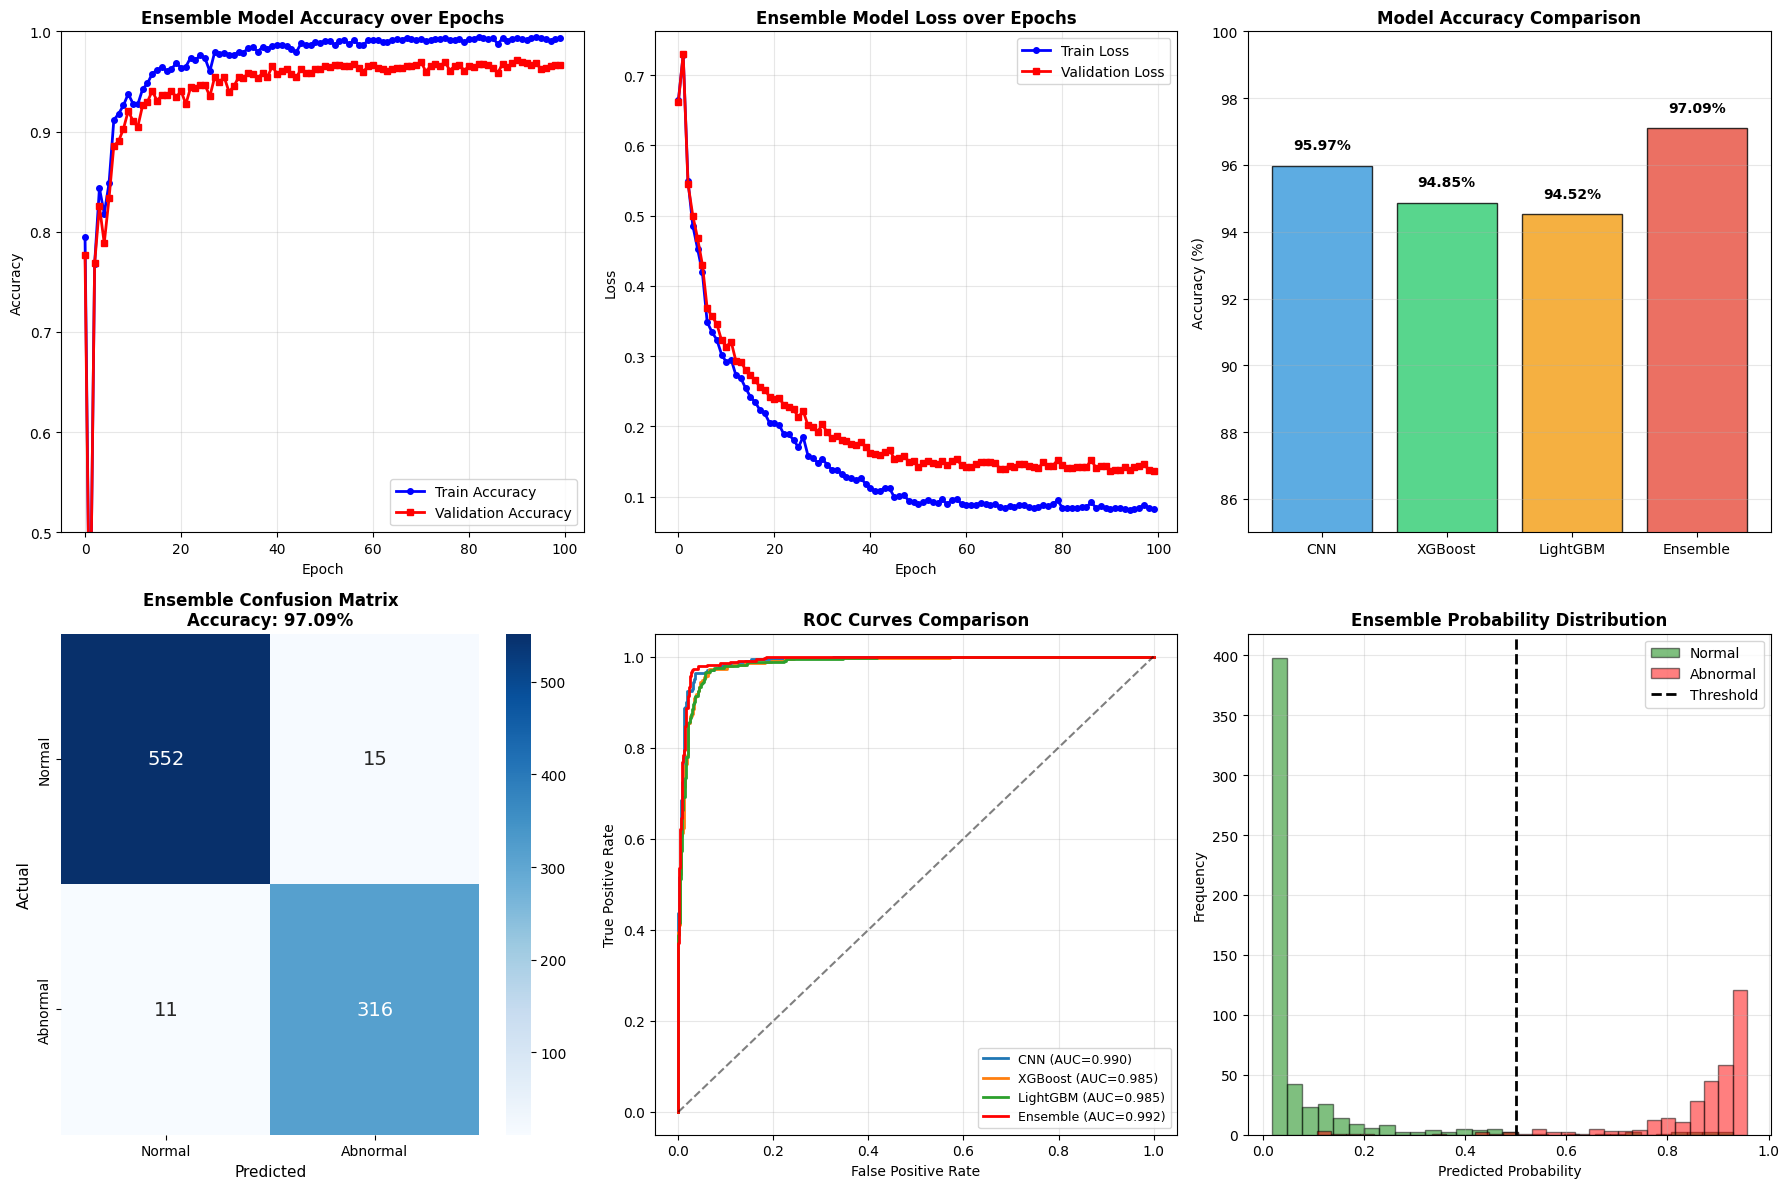

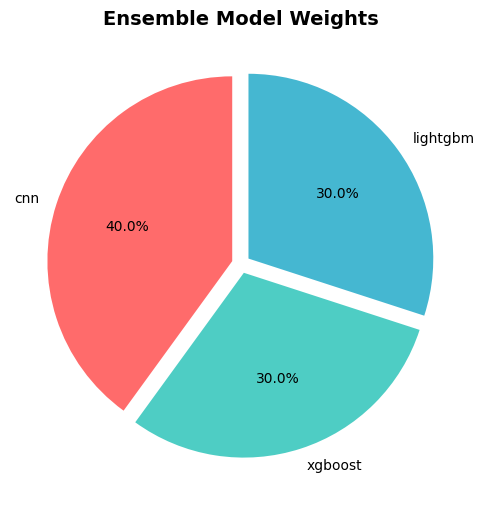


💾 SAVING MODELS
✅ CNN model saved as 'cnn_model.h5'
✅ XGBoost model saved as 'xgboost_model.json'
✅ LightGBM model saved as 'lightgbm_model.txt'
✅ Scaler saved as 'scaler.pkl'
✅ LabelEncoder saved as 'label_encoder.pkl'
✅ Ensemble config saved as 'ensemble_config.pkl'

🎉 ENSEMBLE TRAINING COMPLETE!

🏆 FINAL ENSEMBLE ACCURACY: 97.09%
📊 Improvement over individual models:
   • CNN: 95.97%
   • XGBoost: 94.85%
   • LightGBM: 94.52%
   • Ensemble: 97.09% ← BEST

📈 Training data: 3573 samples (including 1227 augmented)
🔧 Ensemble weights: CNN=0.4, XGB=0.3, LGB=0.3


In [18]:
# ============================================
# 11. الرسومات البيانية
# ============================================

if TRAIN_SETTINGS['show_plots']:
    plt.figure(figsize=(18, 12))
    
    # ===== 1. رسم تطور الـ Ensemble (Accuracy & Loss) =====
    
    # 1A. Ensemble Accuracy
    plt.subplot(2, 3, 1)
    plt.plot(ensemble_train_acc, label='Train Accuracy', linewidth=2, color='blue', marker='o', markersize=4)
    plt.plot(ensemble_val_acc, label='Validation Accuracy', linewidth=2, color='red', marker='s', markersize=4)
    plt.title('Ensemble Model Accuracy over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim([0.5, 1.0])
    
    # 1B. Ensemble Loss
    plt.subplot(2, 3, 2)
    plt.plot(ensemble_train_loss, label='Train Loss', linewidth=2, color='blue', marker='o', markersize=4)
    plt.plot(ensemble_val_loss, label='Validation Loss', linewidth=2, color='red', marker='s', markersize=4)
    plt.title('Ensemble Model Loss over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # ===== 2. مقارنة دقة النماذج =====
    plt.subplot(2, 3, 3)
    models_names = ['CNN', 'XGBoost', 'LightGBM', 'Ensemble']
    accuracies = [
        cnn_accuracy * 100,
        accuracy_score(y_test, (xgb_pred_prob>0.5).astype(int)) * 100,
        accuracy_score(y_test, (lgb_pred_prob>0.5).astype(int)) * 100,
        ensemble_accuracy * 100
    ]
    colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
    bars = plt.bar(models_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
    plt.title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy (%)')
    plt.ylim([85, 100])
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')
    
    # ===== 3. Confusion Matrix للـ Ensemble =====
    plt.subplot(2, 3, 4)
    sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Normal', 'Abnormal'],
               yticklabels=['Normal', 'Abnormal'], annot_kws={'size': 14})
    plt.title(f'Ensemble Confusion Matrix\nAccuracy: {ensemble_accuracy*100:.2f}%', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Predicted', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    
    # ===== 4. ROC Curves =====
    plt.subplot(2, 3, 5)
    from sklearn.metrics import roc_curve
    
    # CNN ROC
    fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_pred_prob)
    auc_cnn = roc_auc_score(y_test, cnn_pred_prob)
    plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC={auc_cnn:.3f})', linewidth=2)
    
    # XGBoost ROC
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_prob)
    auc_xgb = roc_auc_score(y_test, xgb_pred_prob)
    plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', linewidth=2)
    
    # LightGBM ROC
    fpr_lgb, tpr_lgb, _ = roc_curve(y_test, lgb_pred_prob)
    auc_lgb = roc_auc_score(y_test, lgb_pred_prob)
    plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC={auc_lgb:.3f})', linewidth=2)
    
    # Ensemble ROC
    fpr_ens, tpr_ens, _ = roc_curve(y_test, ensemble_probs)
    auc_ens = roc_auc_score(y_test, ensemble_probs)
    plt.plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC={auc_ens:.3f})', linewidth=2, color='red')
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title('ROC Curves Comparison', fontsize=12, fontweight='bold')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(True, alpha=0.3)
    
    # ===== 5. توزيع الاحتمالات للـ Ensemble =====
    plt.subplot(2, 3, 6)
    plt.hist(ensemble_probs[y_test==0], bins=30, alpha=0.5, label='Normal', color='green', edgecolor='black')
    plt.hist(ensemble_probs[y_test==1], bins=30, alpha=0.5, label='Abnormal', color='red', edgecolor='black')
    plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
    plt.title('Ensemble Probability Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ensemble_model_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ===== 6. مخطط أوزان الـ Ensemble (رسم منفصل) =====
    plt.figure(figsize=(6, 6))
    if optimized_weights:
        weights_values = list(optimized_weights.values())
        weights_names = list(optimized_weights.keys())
    else:
        weights_values = list(TRAIN_SETTINGS['ensemble_weights'].values())
        weights_names = list(TRAIN_SETTINGS['ensemble_weights'].keys())
    colors_weights = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    plt.pie(weights_values, labels=weights_names, autopct='%1.1f%%', 
            colors=colors_weights, startangle=90, explode=(0.05, 0.05, 0.05))
    plt.title('Ensemble Model Weights', fontsize=14, fontweight='bold')
    plt.savefig('ensemble_weights.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 12. حفظ النماذج
# ============================================

if TRAIN_SETTINGS['save_model']:
    print("\n" + "="*50)
    print("💾 SAVING MODELS")
    print("="*50)
    
    # حفظ CNN
    cnn_model.save('cnn_model.h5')
    print("✅ CNN model saved as 'cnn_model.h5'")
    
    # حفظ XGBoost
    xgb_model.save_model('xgboost_model.json')
    print("✅ XGBoost model saved as 'xgboost_model.json'")
    
    # حفظ LightGBM
    lgb_model.booster_.save_model('lightgbm_model.txt')
    print("✅ LightGBM model saved as 'lightgbm_model.txt'")
    
    # حفظ الـ Scaler
    joblib.dump(scaler, 'scaler.pkl')
    print("✅ Scaler saved as 'scaler.pkl'")
    
    # حفظ LabelEncoder
    joblib.dump(le, 'label_encoder.pkl')
    print("✅ LabelEncoder saved as 'label_encoder.pkl'")
    
    # حفظ أوزان الـ Ensemble
    ensemble_config = {
        'weights': TRAIN_SETTINGS['ensemble_weights'],
        'optimized_weights': optimized_weights if optimized_weights else TRAIN_SETTINGS['ensemble_weights'],
        'models': ['cnn', 'xgboost', 'lightgbm']
    }
    joblib.dump(ensemble_config, 'ensemble_config.pkl')
    print("✅ Ensemble config saved as 'ensemble_config.pkl'")
    
# ============================================
# 13. التقرير النهائي
# ============================================

print("\n" + "="*70)
print("🎉 ENSEMBLE TRAINING COMPLETE!")
print("="*70)
print(f"\n🏆 FINAL ENSEMBLE ACCURACY: {ensemble_accuracy*100:.2f}%")
print(f"📊 Improvement over individual models:")
print(f"   • CNN: {cnn_accuracy*100:.2f}%")
print(f"   • XGBoost: {accuracy_score(y_test, (xgb_pred_prob>0.5).astype(int))*100:.2f}%")
print(f"   • LightGBM: {accuracy_score(y_test, (lgb_pred_prob>0.5).astype(int))*100:.2f}%")
print(f"   • Ensemble: {ensemble_accuracy*100:.2f}% ← BEST")
print(f"\n📈 Training data: {len(X_train)} samples (including {augmentation_stats['total_augmented']} augmented)")
print(f"🔧 Ensemble weights: CNN={TRAIN_SETTINGS['ensemble_weights']['cnn']}, XGB={TRAIN_SETTINGS['ensemble_weights']['xgboost']}, LGB={TRAIN_SETTINGS['ensemble_weights']['lightgbm']}")
print("="*70)